In [1]:
import torch
import torch.nn as nn

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import io
import numpy as np

from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

In [2]:
df = pd.read_parquet("data/train-00000-of-00008-26f523e9bdcc2b9a.parquet")

In [7]:
sample = df.iloc[1728]

image_bytes = sample['image']['bytes']
image = Image.open(io.BytesIO(image_bytes))

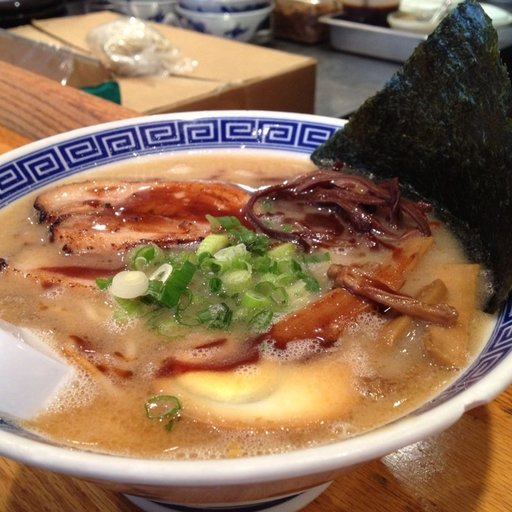

In [8]:
image

In [9]:
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [10]:
class FoodDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ----- Image Bytes → PIL -----
        image_bytes = row["image"]["bytes"]
        image = Image.open(io.BytesIO(image_bytes)).convert("RGB")

        # ----- Transform -----
        if self.transform:
            image = self.transform(image)
        
        return image

In [11]:
dataset = FoodDataset(df, transform=transform)

In [12]:
dataloader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=0)

In [13]:
batch = next(iter(dataloader))

print(batch.shape)

torch.Size([4, 3, 224, 224])


In [14]:
class PatchEmbedding(nn.Module):
    
    def __init__(self, img_size=224, patch_size=16, in_channels=3, embed_dim=768):
        super().__init__()
        
        self.patch_size = patch_size
        
        self.num_patches = (img_size // patch_size) ** 2
        
        self.proj = nn.Linear(
            patch_size * patch_size * in_channels,
            embed_dim
        )
        
    def forward(self, x):
        
        B, C, H, W = x.shape
        
        # ---- Image → patches ----
        x = x.unfold(2, self.patch_size, self.patch_size)
        x = x.unfold(3, self.patch_size, self.patch_size)
        
        # shape: B, C, num_patch_h, num_patch_w, P, P
        
        x = x.contiguous().view(B, C, -1, self.patch_size, self.patch_size)
        
        x = x.permute(0, 2, 1, 3, 4)
        
        # shape: B, num_patches, C, P, P
        
        x = x.flatten(2)
        
        # shape: B, num_patches, patch_dim
        
        x = self.proj(x)
        
        return x

In [15]:
patch_embed = PatchEmbedding()

In [16]:
batch = next(iter(dataloader))

print(batch.shape)

torch.Size([4, 3, 224, 224])


In [17]:
tokens = patch_embed(batch)
tokens.shape

torch.Size([4, 196, 768])

In [18]:
# Patch tokens → [B, N, D]

# B = batch size
# N = total patches (196)
# D = embedding dim

In [19]:
# MAE me kya hota hai?

# 75% patches remove
# 25% patches encoder me
# Masked patches baad me decoder reconstruct karega

# Masking function usually 3 cheeze return karta hai:
# 1. visible tokens
# 2. mask vector
# 3. restore indices (decoder ke liye)

In [20]:
B, N, D = tokens.shape

In [21]:
B, N, D

(4, 196, 768)

In [22]:
mask_ratio=0.75
1 - mask_ratio

0.25

In [23]:
N * (1 - mask_ratio)

49.0

In [24]:
len_keep = int(N * (1 - mask_ratio))

In [25]:
len_keep

49

In [26]:
# ---- random noise generate ----
noise = torch.rand(B, N)

In [28]:
noise.shape

torch.Size([4, 196])

In [31]:
# ---- shuffle indices ----
ids_shuffle = torch.argsort(noise, dim=1)
ids_shuffle.shape

torch.Size([4, 196])

In [33]:
# ---- restore indices ----
ids_restore = torch.argsort(ids_shuffle, dim=1)
ids_restore.shape

torch.Size([4, 196])

In [34]:
# ---- keep first tokens ----
ids_keep = ids_shuffle[:, :len_keep]
ids_keep

tensor([[ 82,  83,  50, 154, 128,  97,  33,  90,  16,  30, 112,  77,  51, 178,
         161, 117,  72, 123, 145,  70, 179,  34,  10, 195, 166, 184, 188, 164,
         114,  22,  45, 127, 153,  27, 159,  62, 138,   9,  59,  73, 192,  69,
         187,  23,  68,  98,  29, 168, 137],
        [116,  61,  17,  46, 169, 135, 149, 172,  77, 154, 178,   3,  41, 183,
          42, 175,  59, 125, 161, 124, 119,  32, 194, 160,  29,  47,  31,  89,
         165, 162,  69,  87,  64,  50,  43,  74,   8,  14, 153,  54, 132,  78,
         118,  57, 193, 112, 120,  20,  24],
        [ 17,  36, 190,  59,  98,  14, 112, 118,  57,   2, 179, 128, 131, 189,
          90, 188,  27,  37,  22,  11,  40,  75,  85,  13, 165, 134, 121, 127,
         161, 140, 178,  43,   6,  29,  81,  38, 104,  32,  16,  89, 162, 144,
          66,  63, 105, 106, 169, 159, 142],
        [ 72,  50,  95,  29, 131, 188, 185,  47, 139,  71, 117, 101, 195, 104,
         148, 126, 171, 140,  57, 130,  67, 121,  91,  13, 177,  18, 141,  

In [35]:
ids_keep.shape

torch.Size([4, 49])

In [39]:
ids_keep.unsqueeze(-1).shape

torch.Size([4, 49, 1])

In [40]:
ids_keep.unsqueeze(-1).repeat(1, 1, D).shape

torch.Size([4, 49, 768])

In [44]:
tokens.shape

torch.Size([4, 196, 768])

In [45]:
x_masked = torch.gather(tokens, dim=1,index=ids_keep.unsqueeze(-1).repeat(1, 1, D))
x_masked.shape

torch.Size([4, 49, 768])

In [50]:
# ---- create mask ----
mask = torch.ones(B, N)
mask.shape

torch.Size([4, 196])

In [51]:
mask

tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1.

In [52]:
mask[:, :len_keep] = 0

In [53]:
mask

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.

In [54]:
# unshuffle mask
mask = torch.gather(mask, dim=1, index=ids_restore)

In [55]:
mask

tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 1., 0., 1.,
         1., 1., 1., 1., 0., 0., 1., 1., 1., 0., 1., 0., 0., 1., 1., 0., 0., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 0., 0., 1., 1.,
         1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 1., 1., 1., 1., 0., 0., 0., 1.,
         0., 0., 1., 1., 1., 0., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 1., 1.,
         0., 1., 1., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 0., 1., 0., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1., 1.,
         1., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 1.,
         1., 0., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 0., 1., 0.,
         1., 1., 0., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0.,
         1., 1., 1., 1., 0., 1., 1., 0., 0., 1., 1., 1., 0., 1., 1., 0.],
        [1., 1., 1., 0., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 0.,
         1., 1., 0., 1., 1., 1., 0.

In [56]:
# Sabse pehle — MAE masking karta kya hai?

# MAE ka idea:
# Image ke kuch patches hide kar do
# Model ko bolo missing patches reconstruct karo

# Exactly jaise:
# Fill in the blanks

# Input
# x: [B, N, D]

# B → batch size
# N → number of patches (tokens)
# D → embedding dimension

# [4, 196, 768]

# Step 1 — Batch dimensions
# B, N, D = x.shape
# Bas shape unpack kar rahe hain.

# Step 2 — Kitne patches rakhne hain
# len_keep = int(N * (1 - mask_ratio))

# mask_ratio = 0.75

# Matlab:
# 75% patches hide
# 25% patches keep

# N = 196
# len_keep = 49

# Step 3 — Random noise generate
# noise = torch.rand(B, N)

# Ye har patch ko ek random score deta hai.
# [0.12, 0.89, 0.34, 0.01, ...]

# Ye kyu karte hain?

# Taaki randomly decide kar sake:
# kaunse patches hide
# kaunse patches keep

# Step 4 — Shuffle indices
# ids_shuffle = torch.argsort(noise, dim=1)

# Noise ko ascending order me sort kar diya
# Isse random patch order mil gaya

# Original patches → 0 1 2 3 4
# Noise           → 0.7 0.1 0.5 0.2 0.9
# Sorted indices  → 1 3 2 0 4

# Step 5 — Restore indices
# ids_restore = torch.argsort(ids_shuffle, dim=1)

# Ye inverse permutation hota hai.
# Baad me patches ko original order me laane ke liye use hota hai

# Ye MAE me extremely important hota hai
# Decoder reconstruction ke time use hota hai.

# Step 6 — Tokens choose karna
# ids_keep = ids_shuffle[:, :len_keep]

# Sorted list me se first tokens select kar liye
# Ye kept tokens hain

# [1, 3, 2, 0, 4]
# keep first 2 → [1, 3]

# Step 7 — Actual masking apply
# x_masked = torch.gather(...)

# Gather kya karta hai?
# Tensor se specific indices pick karta hai

# x → original tokens
# ids_keep → jo tokens rakhne hain

# unsqueeze(-1).repeat(1,1,D)
# Ye trick hai:
# Gather ko D dimension ke liye indices chahiye
# Isliye expand kar rahe ho

# Output
# x_masked → [B, len_keep, D]
# [4, 49, 768]

# Step 8 — Mask vector banana
# mask = torch.ones(B, N)
# mask[:, :len_keep] = 0

# 0 → token kept
# 1 → token masked

# Abhi mask shuffled order me hai.

# Step 9 — Mask ko original order me lana
# mask = torch.gather(mask, dim=1, index=ids_restore)

# Ye bahut important step hai.
# Mask ko original patch order me wapas la rahe ho

# Full Intuition Flow
# Tokens → Random shuffle
#         → First few tokens keep
#         → Remaining hide
#         → Mask create
#         → Restore order mapping store

In [57]:
# Ek subtle but killer insight

# Ye approach:

# Random tokens remove karta hai
# But spatial information indirectly maintain karta hai
# ids_restore isi ka backbone hai

In [1]:
def random_masking(x, mask_ratio=0.75):
    
    """
    x: [B, N, D]
    """
    
    B, N, D = x.shape
    
    len_keep = int(N * (1 - mask_ratio))
    
    # ---- random noise generate ----
    noise = torch.rand(B, N, device=x.device)
    
    # ---- shuffle indices ----
    ids_shuffle = torch.argsort(noise, dim=1)
    ids_restore = torch.argsort(ids_shuffle, dim=1)
    
    # ---- keep first tokens ----
    ids_keep = ids_shuffle[:, :len_keep]
    
    x_masked = torch.gather(
        x,
        dim=1,
        index=ids_keep.unsqueeze(-1).repeat(1, 1, D)
    )
    
    # ---- create mask ----
    mask = torch.ones(B, N, device=x.device)
    mask[:, :len_keep] = 0
    
    # unshuffle mask
    mask = torch.gather(mask, dim=1, index=ids_restore)
    
    return x_masked, mask, ids_restore